# Лабораторная работа: Генеративные модели классификации (LDA и Naive Bayes)

## Общая цель работы
Изучить генеративный подход к классификации на примере двух моделей: **Линейный дискриминантный анализ (LDA)** и **Наивный байесовский классификатор (NB)**. Вы не просто реализуете алгоритмы, а исследуете, как предположения о структуре данных (ковариация, независимость признаков) влияют на разделяющую поверхность и качество классификации.

---

## Теоретическое введение (обязательно к прочтению)

### Генеративный vs дискриминативный подход
- **Дискриминативные модели** (логистическая регрессия, SVM) моделируют границу между классами напрямую: $ p(y|x) $.
- **Генеративные модели** моделируют совместное распределение $ p(x, y) = p(x|y) \cdot p(y) $, а затем через теорему Байеса получают $ p(y|x) $.

### Байесовский классификатор
Для задачи классификации с $ K $ классами:
$
\hat{y} = \arg\max_{y} p(y|x) = \arg\max_{y} \frac{p(x|y) \cdot p(y)}{p(x)} = \arg\max_{y} p(x|y) \cdot p(y)
$

Где:
- $ p(y) $ — **априорная вероятность** класса (оценивается как доля объектов класса в выборке).
- $ p(x|y) $ — **правдоподобие** (likelihood) — вероятность наблюдать объект $ x $ в классе $ y $.

### Два подхода к моделированию правдоподобия

**1. LDA (Линейный дискриминантный анализ)**
- Предполагает, что $ p(x|y) $ — многомерное нормальное распределение.
- **Ключевое допущение:** матрицы ковариации для всех классов **одинаковы**: $ C_0 = C_1 = ... = C $.
- **Следствие:** разделяющая поверхность между классами является **линейной** (гиперплоскостью).
- Параметры для каждого класса: $ \mu_y $ (среднее) и общая $ C $.

**2. Наивный байесовский классификатор (NB)**
- Также предполагает нормальное распределение $ p(x|y) $, но **без учета корреляций** между признаками.
- **Ключевое допущение:** признаки условно независимы при заданном классе:
  $
  p(x_1, x_2, ..., x_n|y) = \prod_{i=1}^{n} p(x_i|y)
  $
- **Следствие:** матрица ковариации для каждого класса **диагональная** (все внедиагональные элементы = 0).
- Параметры для каждого класса: $ \mu_y $ и $ \sigma_{y,i}^2 $ (дисперсия каждого признака отдельно).

**Важно:** LDA и NB — частные случаи одного и того же байесовского подхода, различающиеся структурой ковариационной матрицы:
- LDA: одна полная матрица ковариации $ C $ для всех классов.
- NB: отдельная диагональная матрица для каждого класса.

---

## Часть 1. Исследование многомерного нормального распределения (10 баллов)

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

---

## Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

---

## Часть 3. Бинарная классификация через байесовский подход (15 баллов)

**Цель:** визуализировать разделяющую поверхность для двух классов.

### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?

---

## Часть 4. Линейный дискриминантный анализ (LDA) (20 баллов)

### 4.1 Теоретический вывод (в тетради)
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону:

```python
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass
```

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $
  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

### 4.3 Проверка на синтетике
- Создайте два класса с одинаковой ковариацией $ C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix} $, но разными средними.
- Обучите ваш `MyLDA` и сравните предсказания с `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.
- Визуализируйте разделяющую прямую и точки.

**Автопроверка:**
```python
# Сравнение с sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
```

---

## Часть 5. Наивный байесовский классификатор (NB) (20 баллов)

### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

### 5.2 Реализация класса NB
Реализуйте класс `MyNB`:

```python
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        pass
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        pass
```

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$

### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

**Автопроверка:**
```python
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
```

---

## Часть 6. Экспериментальное сравнение LDA и NB (15 баллов)

### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.

### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

---

## Критерии оценки (максимум 85 баллов)

| Часть | Баллы | Что проверяется |
|-------|-------|-----------------|
| 1.1 Генерация и поворот | 5 | Корректная генерация, визуализация, сравнение ковариаций |
| 1.2 Сравнение с `multivariate_normal` | 5 | Понимание способов генерации |
| 2. PDF и визуализация | 5 | Ручное вычисление, сравнение со scipy |
| 3. Бинарная классификация | 10 | Правильная визуализация Δ и разделяющей поверхности |
| 4.1 Теоретический вывод LDA | 5 | Формулы для w и b |
| 4.2 Реализация MyLDA | 10 | Код, совместимость со sklearn API |
| 4.3 Проверка на синтетике | 5 | Сравнение с sklearn, визуализация |
| 5.1 Теория NB | 5 | Понимание условной независимости |
| 5.2 Реализация MyNB | 10 | Код, логарифмическое правдоподобие |
| 5.3 Проверка с sklearn | 5 | Совпадение предсказаний |
| 6.1 Генерация 3 датасетов | 5 | Разнообразие структур |
| 6.2 Эксперименты и метрики | 10 | Все метрики, confusion matrix |
| 6.3 Анализ и выводы | 10 | Глубокий анализ результатов |
| **Стиль кода и оформление** | **Бонус +5** | Чистый код, комментарии, структура ноутбука |

---

## Полезные функции и материалы

### Генерация датасета с заданной ковариацией
```python
def generate_gaussian_class(mean, cov, n_samples=300):
    return np.random.multivariate_normal(mean, cov, n_samples)

# Пример создания двух классов
X0 = generate_gaussian_class(mean0, cov0, 300)
X1 = generate_gaussian_class(mean1, cov1, 300)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(300), np.ones(300)])
```

### Вычисление разделяющей поверхности
```python
def decision_function(X, means, cov, priors):
    """Возвращает разность логарифмов апостериорных вероятностей"""
    log_p0 = np.log(priors[0]) + multivariate_normal(means[0], cov).logpdf(X)
    log_p1 = np.log(priors[1]) + multivariate_normal(means[1], cov).logpdf(X)
    return log_p1 - log_p0  # >0 => класс 1, <0 => класс 0
```

---

## Рекомендации по оформлению

1. Каждая часть должна быть отдельным разделом с заголовком.
2. Код должен быть прокомментирован (на русском или английском).
3. Все графики должны иметь подписи осей и легенды.
4. В конце каждой части — краткий вывод (1-2 предложения).
5. Итоговый вывод — развернутый (10+ предложений) с ответами на все поставленные вопросы.

---

Это задание теперь требует не только написания кода, но и **понимания теории** через визуализацию и эксперименты. Все блоки с проверками помогут студентам самостоятельно убедиться в корректности решения, а преподавателю — быстро оценить работу.

Выборочная ковариационная матрица:
[[ 0.5968187  -1.02297876]
 [-1.02297876  1.78467602]]

Теоретическая ковариационная матрица:
[[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]

✅ Все проверки пройдены!


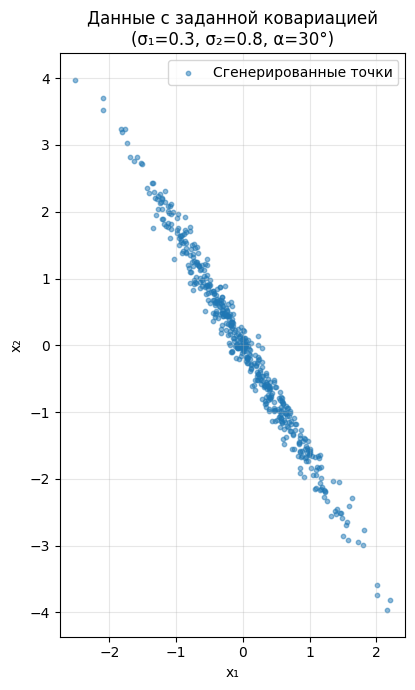

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
M = 500
sigma1 = 0.3
sigma2 = 0.8
alpha = np.deg2rad(30)

# Шаг 1: генерация независимых векторов
x1 = np.random.normal(0, sigma1**2, M)
x2 = np.random.normal(0, sigma2*2, M)
# размер (M, 2)
X_old = np.column_stack([x1, x2])   

# Шаг 2: поворот на угол α
R = np.array([[np.cos(alpha), -np.sin(alpha)],
              [np.sin(alpha),  np.cos(alpha)]])
# применяем поворот
X = X_old @ R.T
# X.shape == (M, 2)

#  Шаг 3: выборочная ковариационная матрица
C_sample = np.cov(X.T)
print("Выборочная ковариационная матрица:")
print(C_sample)

#  Шаг 4: теоретическая ковариационная матрица
D = np.diag([sigma1**2, sigma2**2])
C_theor = R @ D @ R.T
print("\nТеоретическая ковариационная матрица:")
print(C_theor)



#  Автопроверка
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
print("\n✅ Все проверки пройдены!")



# Визуализация
fig, ax = plt.subplots(figsize=(7, 7))

# Scatter plot
ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.5, label='Сгенерированные точки')

# Эллипсы равной плотности (уровни 0.5, 1, 2 σ)
xx, yy = np.meshgrid(np.linspace(-3, 3, 400), np.linspace(-3, 3, 400))
pos = np.dstack([xx, yy])

from scipy.stats import multivariate_normal
rv = multivariate_normal(mean=[0, 0], cov=C_theor)

# Плотность на уровнях k·σ: pdf = exp(-k²/2) / (2π|Σ|^½)
# levels = [rv.pdf([0, 0]) * np.exp(-k**2 / 2) for k in [0.5, 1, 2]]
# ax.contour(xx, yy, rv.pdf(pos), levels=levels, colors='red', linewidths=2,
#            labels=['0.5σ', '1σ', '2σ'])

ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Данные с заданной ковариацией\n(σ₁=0.3, σ₂=0.8, α=30°)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ── 2. Генерация данных ──────────────────────────────────────
# Способ А: Ручная генерация (через поворот независимых выборок)
np.random.seed(42)
X_raw = np.column_stack([
    np.random.normal(0, sigma1, M),
    np.random.normal(0, sigma2, M)
])
X_manual = X_raw @ R.T

# Способ Б: Встроенная функция multivariate_normal
np.random.seed(123) # Другой seed, чтобы точки визуально не сливались
X_builtin = np.random.multivariate_normal(
    mean=[0, 0], 
    cov=C_theor, 
    size=M
)

# ── 3. Визуализация на одном графике ─────────────────────────
plt.figure(figsize=(8, 6))

# Облако ручной генерации (синие круги)
plt.scatter(X_manual[:, 0], X_manual[:, 1], 
            s=15, alpha=0.5, color='blue', 
            label='Ручная генерация (X_raw @ R.T)', edgecolors='none')

# Облако встроенной функции (красные крестики)
plt.scatter(X_builtin[:, 0], X_builtin[:, 1], 
            s=15, alpha=0.5, color='red', marker='x', 
            label='np.random.multivariate_normal', edgecolors='none')

plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.title('Сравнение методов генерации многомерного нормального распределения', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.axis('equal')  # Сохраняем пропорции, чтобы эллипс не искажался
plt.tight_layout()
plt.show()

# ── 4. Численная проверка ────────────────────────────────────
print("Теоретическая ковариационная матрица:")
print(np.round(C_theor, 4))
print("\nВыборочная ковариация (ручной метод):")
print(np.round(np.cov(X_manual.T), 4))
print("\nВыборочная ковариация (встроенная функция):")
print(np.round(np.cov(X_builtin.T), 4))

In [ ]:
# Оценка параметров по данным из части 1.1
mu = np.mean(X, axis=0)
C = np.cov(X.T)

# Сетка в диапазоне [-2, 2]
x_grid = np.linspace(-2, 2, 300)
y_grid = np.linspace(-2, 2, 300)
grid_x, grid_y = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([grid_x.ravel(), grid_y.ravel()])

# PDF с помощью scipy
m = multivariate_normal(mean=mu, cov=C)
pdf_scipy = m.pdf(grid_points)

# Ручное вычисление PDF
n_features = X.shape[1]
C_inv = np.linalg.inv(C)
C_det = np.linalg.det(C)
diff = grid_points - mu

pdf_manual = (
    1 / np.sqrt((2 * np.pi) ** n_features * C_det)
    * np.exp(-0.5 * np.einsum('ij,jk,ik->i', diff, C_inv, diff))
)

# Проверка совпадения
max_difference = np.max(np.abs(pdf_manual - pdf_scipy))
print("Оцененное среднее:", mu)
print("Выборочная ковариация:\n", C)
print("Максимальная разница:", max_difference)

assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), \
    "Ручное вычисление отличается от scipy"
print("✅ Проверка PDF пройдена")

# Визуализация
pdf_grid = pdf_scipy.reshape(grid_x.shape)

plt.figure(figsize=(8, 6))

filled = plt.contourf(
    grid_x, grid_y, pdf_grid,
    levels=20,
    cmap='viridis'
)
plt.colorbar(filled, label='Плотность вероятности')

contours = plt.contour(
    grid_x, grid_y, pdf_grid,
    levels=10,
    colors='black',
    linewidths=0.7
)
plt.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

plt.scatter(
    X[:, 0], X[:, 1],
    s=12, c='red', alpha=0.45,
    label='Исходные точки'
)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Плотность двумерного нормального распределения')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()